# Goal: Inspect the M1 vs M2 plot

In particular look at mass ratios (maybe fit them)

(LvS: 06-02-26)

In [1]:
import json
import numpy as np
import pandas as pd
import sys, os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR, DOCS_DIR, LATEX_PLOT_DIR

file_path = MAIN_CATALOG


# Use mathtext (LaTeX-like without needing LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern math font
plt.rcParams['font.size'] = 12


In [2]:
# Helper function to increase darkness of a color
def darken_color(color, factor=0.7):
    """
    Darken a color by multiplying its RGB values by a factor.
    color : str or tuple Color as hex string (e.g., '#FF0000') or RGB tuple
    factor : float Factor to darken by (0-1). Lower = darker. Default 0.7 
    Returns:
    str : Darkened color as hex string
    """
    import matplotlib.colors as mcolors
    # Convert to RGB if it's a hex string
    rgb = mcolors.to_rgb(color)
    # Multiply each channel by the factor
    darkened_rgb = tuple(c * factor for c in rgb)
    # Convert back to hex
    return mcolors.to_hex(darkened_rgb)



### Read json catalog into pandas table

In [3]:
# === Load JSON ===
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

def extract_triplet_array(data, key):
    """Return an (N,3) float array for the given triplet key, robust to None/NaN."""
    rows = []
    for entry in data:
        val = entry.get(key, None)
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 3:
            try:
                # Convert None to np.nan before float conversion
                rows.append([
                    np.nan if val[0] is None else float(val[0]),
                    np.nan if val[1] is None else float(val[1]),
                    np.nan if val[2] is None else float(val[2])
                ])
            except (TypeError, ValueError):
                rows.append([np.nan, np.nan, np.nan])
        elif isinstance(val, (int, float)):
            # Scalar provided, treat as central value with unknown errors
            rows.append([np.nan, float(val), np.nan])
        else:
            rows.append([np.nan, np.nan, np.nan])
    return np.array(rows, dtype=float)

In [4]:
# Read data
data = read_json_file(str(MAIN_CATALOG))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)


In [5]:
# Extract triplet columns once for efficiency/consistency
RA_arr = extract_triplet_array(data, 'RA')
Dec_arr = extract_triplet_array(data, 'Dec')
period_arr = extract_triplet_array(data, 'Period')
ecc_arr = extract_triplet_array(data, 'Eccentricity')
m1_arr = extract_triplet_array(data, 'M1')
m2_arr = extract_triplet_array(data, 'M2')

# Build a single DataFrame with central values and errors
catalog_df = pd.DataFrame({
    'System Name': [entry.get('System Name', '') for entry in data],
    'RA': RA_arr[:, 1],
    'Dec': Dec_arr[:, 1],
    'Period': period_arr[:, 1],
    'Period_err_minus': period_arr[:, 0],
    'Period_err_plus': period_arr[:, 2],
    'Eccentricity': ecc_arr[:, 1],
    'Eccentricity_err_minus': ecc_arr[:, 0],
    'Eccentricity_err_plus': ecc_arr[:, 2],
    'M1': m1_arr[:, 1],
    'M1_err_minus': m1_arr[:, 0],
    'M1_err_plus': m1_arr[:, 2],
    'M2': m2_arr[:, 1],
    'M2_err_minus': m2_arr[:, 0],
    'M2_err_plus': m2_arr[:, 2],
    'obs_type_1': [entry.get('obs_type_1', '') for entry in data],
    'obs_type_2': [entry.get('obs_type_2', '') for entry in data],
    'evol_type_1': [entry.get('evol_type_1', '') for entry in data],
    'evol_type_2': [entry.get('evol_type_2', '') for entry in data],
    'system_class': [entry.get('system_class', 'None') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})

In [6]:
display(catalog_df)

,System Name,RA,Dec,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,...,M1_err_plus,M2,M2_err_minus,M2_err_plus,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
0,Cl* NGC 188 PKM 451,8.700020,85.540940,722.000000,4.000000e+00,4.000000e+00,0.34,0.03,0.03,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
1,Cl* NGC 188 PKM 1888,13.631330,85.535900,2240.000000,3.000000e+01,3.000000e+01,0.21,0.04,0.04,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
2,Cl* NGC 188 PKM 2679,6.685930,85.310000,1033.000000,8.000000e+00,8.000000e+00,0.07,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
3,Cl* NGC 188 PKM 4348,10.923210,85.221480,1168.000000,8.000000e+00,8.000000e+00,0.09,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4,Cl* NGC 188 PKM 4540,11.326540,85.322200,3030.000000,7.000000e+01,7.000000e+01,0.36,0.07,0.07,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4704,UCAC4 495-142916,297.473341,8.904363,0.748668,1.600000e-06,1.600000e-06,NaN,NaN,NaN,1.69,...,0.07,0.31,0.07,0.07,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4705,CRTS J225539.4+342138,118.713529,34.360512,0.571785,3.000000e-07,3.000000e-07,NaN,NaN,NaN,1.40,...,0.04,0.26,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4706,UCAC4 646-116578,123.282814,39.139678,0.766129,3.800000e-06,3.800000e-06,NaN,NaN,NaN,1.60,...,0.08,0.16,0.05,0.05,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4707,ZTF J225755.64+310133.7,127.228463,31.026046,0.688416,4.000000e-07,4.000000e-07,NaN,NaN,NaN,1.65,...,0.06,0.29,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [7]:
# System-class colours and symbols — imported from the shared module.
# Edit code/data_analysis/Category_dict.py to change colours/symbols everywhere.
import importlib
import Category_dict as category_dict

importlib.reload(category_dict)  # Pick up latest edits without restarting the kernel

SYSTEM_CLASS_MAP = category_dict.SYSTEM_CLASS_MAP
STYLE_MAP = category_dict.STYLE_MAP
COLORMAP = category_dict.COLORMAP
SYMBOLMAP = category_dict.SYMBOLMAP


In [8]:
# Helper function to increase darkness of a color
def darken_color(color, factor=0.7):
    """
    Darken a color by multiplying its RGB values by a factor.
    
    Parameters:
    -----------
    color : str or tuple
        Color as hex string (e.g., '#FF0000') or RGB tuple
    factor : float
        Factor to darken by (0-1). Lower = darker. Default 0.7
        
    Returns:
    --------
    str : Darkened color as hex string
    """
    import matplotlib.colors as mcolors
    
    # Convert to RGB if it's a hex string
    rgb = mcolors.to_rgb(color)
    
    # Multiply each channel by the factor
    darkened_rgb = tuple(c * factor for c in rgb)
    
    # Convert back to hex
    return mcolors.to_hex(darkened_rgb)

# Example usage:
# darker_green = darken_color(mass_colors[0], factor=0.6)
# ax.plot(x, y, color=darker_green)

# Plot M1 vs M2 per category: log x and y

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


Ongoing RLOF:
  log M2 = 1.330+/-0.042 * log M1 + -0.684+/-0.034
Low-M stripped:
  log M2 = -0.026+/-0.038 * log M1 + -0.454+/-0.021
High-M stripped:
  log M2 = 0.457+/-0.290 * log M1 + 0.623+/-0.366
WD binary:
  log M2 = -0.085+/-0.009 * log M1 + -0.234+/-0.002
CO binary:
  log M2 = 0.103+/-0.068 * log M1 + 0.229+/-0.055


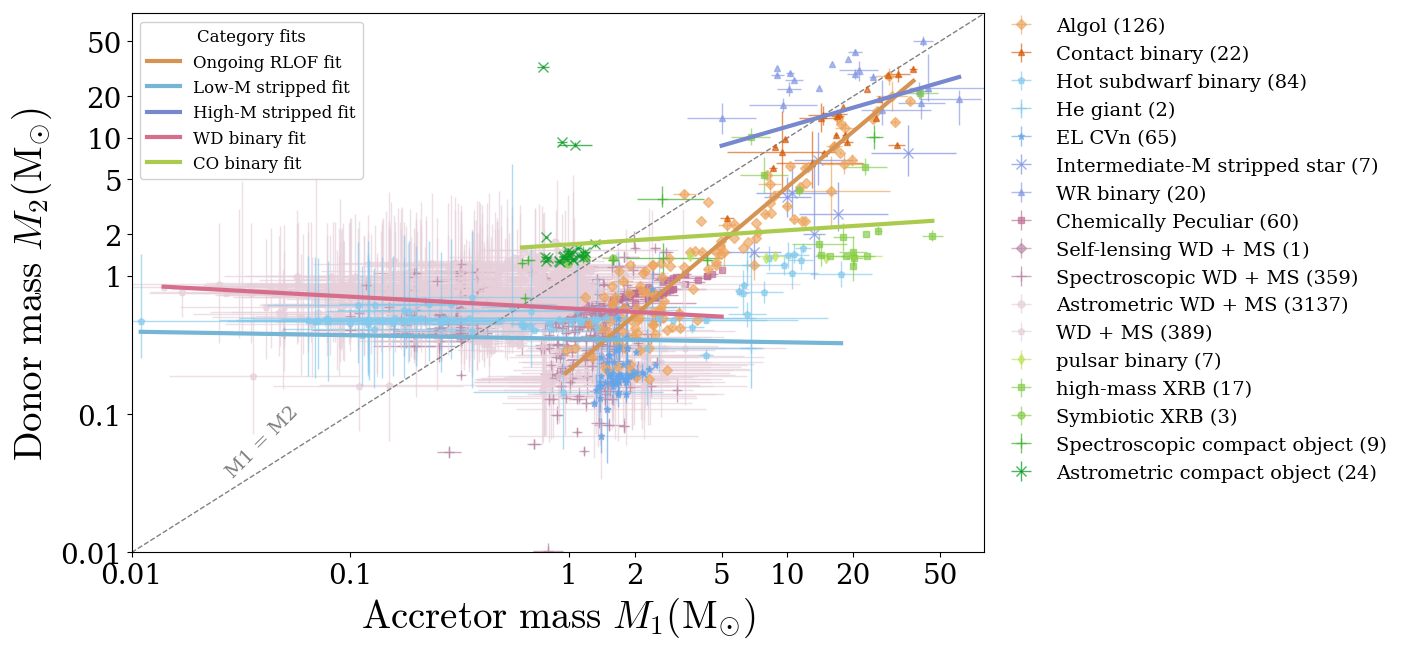

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

plot_df = catalog_df.copy()

###### Prepare log-space quantities ######
# Keep only positive masses for log10 scaling
plot_df = plot_df[(plot_df['M1'] > 0) & (plot_df['M2'] > 0)].copy()
plot_df['log_M1'] = np.log10(plot_df['M1'])
plot_df['log_M2'] = np.log10(plot_df['M2'])

# Propagate errors for logM1 and logM2: d(log M) = dM / (M ln 10)
plot_df['M1_err_minus_log'] = (plot_df['M1_err_minus'] / (plot_df['M1'] * np.log(10))).fillna(0)
plot_df['M1_err_plus_log'] = (plot_df['M1_err_plus'] / (plot_df['M1'] * np.log(10))).fillna(0)
plot_df['M2_err_minus_log'] = (plot_df['M2_err_minus'] / (plot_df['M2'] * np.log(10))).fillna(0)
plot_df['M2_err_plus_log'] = (plot_df['M2_err_plus'] / (plot_df['M2'] * np.log(10))).fillna(0)

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': '+',
    'cross-dot': '+',
    'plus': '+',
    '+': '+',
    'x': 'x',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
}

# Build legend handle lists separately for class points and category fits.
class_handles = []
fit_handles = []

###### Plot all system classes separately ######
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class].copy()
    if sub.empty:
        continue

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    if system_class in SYSTEM_CLASS_MAP["WD binary"]:
        zoder = 0 
    else:        
        zoder = 2

    class_plot = ax.errorbar(
        sub['log_M1'], sub['log_M2'],
        xerr=[sub['M1_err_minus_log'], sub['M1_err_plus_log']],
        yerr=[sub['M2_err_minus_log'], sub['M2_err_plus_log']],
        fmt=marker_mpl, ms=7 if marker_mpl in ['+', 'x'] else 5,
        c=color, ecolor=color, elinewidth=1, capsize=0,
        alpha=0.75 if marker_mpl in ['+', 'x'] else 0.65,
        zorder=zoder,
        label=f"{system_class} ({len(sub)})"
    )
    class_handles.append(class_plot)

###### Keep category fits from combined category subsets ######
for category, systems in SYSTEM_CLASS_MAP.items():
    system_classes_in_category = list(systems.keys())
    subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)].copy()

    fit_df = subset.dropna(subset=['log_M1', 'log_M2'])
    if len(fit_df) < 2:
        continue

    # Define linear function in log space: log M2 = a * log M1 + b
    def linear_func(x, a, b):
        return a * x + b

    # Perform curve_fit on the whole category
    popt, pcov = curve_fit(linear_func, fit_df['log_M1'], fit_df['log_M2'])

    # Generate smooth curve for plotting
    x_fit = np.linspace(fit_df['log_M1'].min(), fit_df['log_M1'].max(), 100)
    y_fit = linear_func(x_fit, *popt)

    # Use the first class color in the category for the fit line
    first_system_color = list(systems.values())[0]['color']
    fit_color = darken_color(first_system_color, factor=0.9)

    # Plot category fit
    fit_line, = ax.plot(x_fit, y_fit, color=fit_color, linewidth=3, zorder=10, label=f"{category} fit")
    fit_handles.append(fit_line)

    # Print fit results
    a, b = popt
    perr = np.sqrt(np.diag(pcov))
    a_err, b_err = perr
    print(f"{category}:")
    print(f"  log M2 = {a:.3f}+/-{a_err:.3f} * log M1 + {b:.3f}+/-{b_err:.3f}")

# Show x=y line for reference in log space
ax.plot(np.linspace(-2, 2), np.linspace(-2, 2), color='gray', linestyle='--', linewidth=1)
ax.text(-1.4, -1.2, 'M1 = M2', color='gray', fontsize=16, ha='center', va='center', rotation=45)

# Write x and y ticks in non-log values
ax.set_xticks([-2, -1, 0, np.log10(2), np.log10(5), 1, np.log10(20), np.log10(50)])
ax.set_xticklabels(['0.01', '0.1', '1', '2', '5', '10', '20', '50'], fontsize=20)
ax.set_yticks([-2, -1, 0, np.log10(2), np.log10(5), 1, np.log10(20), np.log10(50)])
ax.set_yticklabels(['0.01', '0.1', '1', '2', '5', '10', '20', '50'], fontsize=20)


# Separate legends: classes outside in figure coords, fits inside top-left.
legend_fits = ax.legend(
    handles=fit_handles,
    fontsize=12,
    loc='upper left',
    title='Category fits',
    framealpha=0.9
    )

legend_classes = ax.legend(
    handles=class_handles,
    fontsize=14, ncols=1,
    bbox_to_anchor=(0.9, 0.9), loc='upper left',
    bbox_transform=fig.transFigure, framealpha=0. )

ax.add_artist(legend_fits)

# Plot formatting
plt.xlim(-2, 1.9)
plt.ylim(-2, 1.9)
plt.xlabel('$\mathrm{Accretor \ mass} \ M_1 \mathrm{(M_{\odot})}$', fontsize=28)
plt.ylabel('$\mathrm{Donor \ mass} \ M_2 \mathrm{(M_{\odot})}$', fontsize=28)

# plt.savefig(LATEX_PLOT_DIR / 'M1_M2_log_fit.pdf', bbox_inches='tight')
plt.savefig(PLOTS_DIR / 'M1_M2_log_fit.pdf', bbox_inches='tight')
plt.show()


# Only fit the Algols

Ongoing RLOF:
  log M2 = 1.330+/-0.042 * log M1 + -0.684+/-0.034
Low-M stripped:
  log M2 = 0.311+/-0.041 * (log M1)^2 + 0.073+/-0.035 * log M1 + -0.553+/-0.022


/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


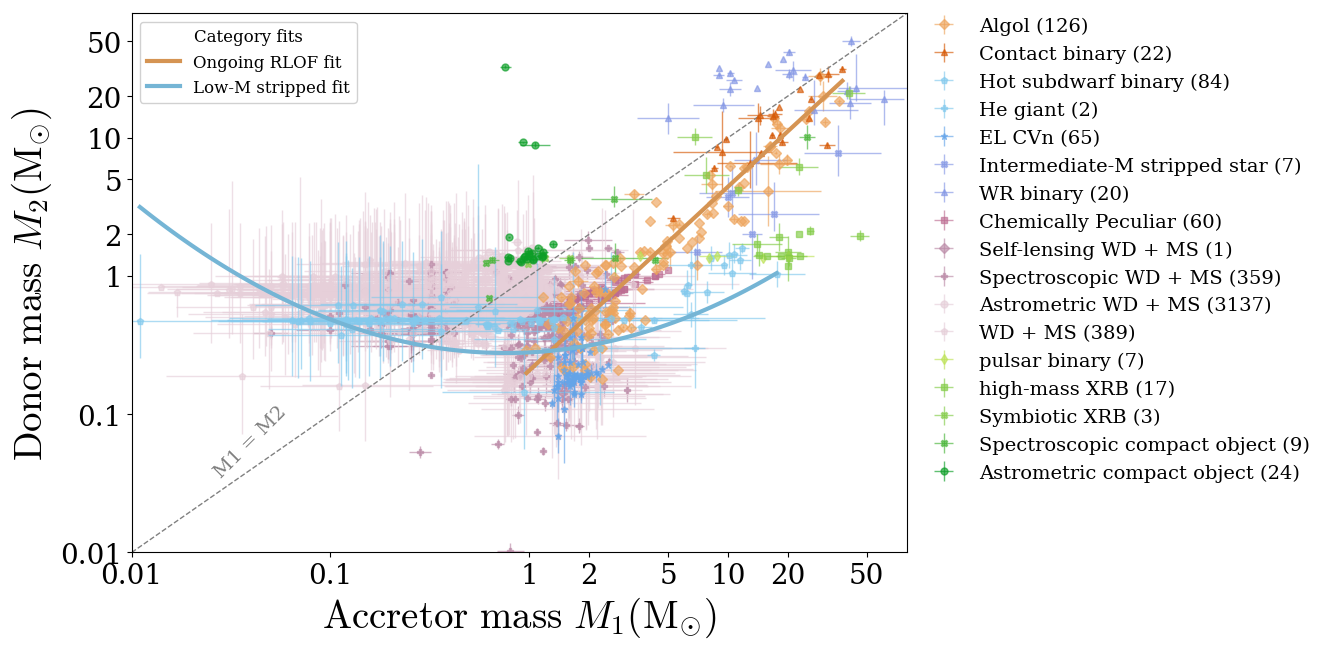

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

plot_df = catalog_df.copy()

###### Prepare log-space quantities ######
# Keep only positive masses for log10 scaling
plot_df = plot_df[(plot_df['M1'] > 0) & (plot_df['M2'] > 0)].copy()
plot_df['log_M1'] = np.log10(plot_df['M1'])
plot_df['log_M2'] = np.log10(plot_df['M2'])

# Propagate errors for logM1 and logM2: d(log M) = dM / (M ln 10)
plot_df['M1_err_minus_log'] = (plot_df['M1_err_minus'] / (plot_df['M1'] * np.log(10))).fillna(0)
plot_df['M1_err_plus_log'] = (plot_df['M1_err_plus'] / (plot_df['M1'] * np.log(10))).fillna(0)
plot_df['M2_err_minus_log'] = (plot_df['M2_err_minus'] / (plot_df['M2'] * np.log(10))).fillna(0)
plot_df['M2_err_plus_log'] = (plot_df['M2_err_plus'] / (plot_df['M2'] * np.log(10))).fillna(0)

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': 'P',
    'cross-dot': 'P',
    'x': 'X',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
}

# Build legend handle lists separately for class points and category fits.
class_handles = []
fit_handles = []

###### Plot all system classes separately ######
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class].copy()
    if sub.empty:
        continue

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    if system_class in SYSTEM_CLASS_MAP["WD binary"]:
        zoder = 0 
    else:        
        zoder = 2

    class_plot = ax.errorbar(
        sub['log_M1'], sub['log_M2'],
        xerr=[sub['M1_err_minus_log'], sub['M1_err_plus_log']],
        yerr=[sub['M2_err_minus_log'], sub['M2_err_plus_log']],
        fmt=marker_mpl, ms=5, c=color, ecolor=color, elinewidth=1, capsize=0,
        alpha=0.65, zorder=zoder,
        label=f"{system_class} ({len(sub)})"
    )
    class_handles.append(class_plot)

###### Keep category fits from combined category subsets ######
for category, systems in SYSTEM_CLASS_MAP.items():
    if category in ['High-M stripped', 'CO binary', 'WD binary']:
        continue  # 
    system_classes_in_category = list(systems.keys())
    subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)].copy()

    fit_df = subset.dropna(subset=['log_M1', 'log_M2'])
    if len(fit_df) < 2:
        continue

    # Define linear function in log space: log M2 = a * log M1 + b
    def linear_func(x, a, b):
        return a * x + b
    
    # Define a quadratic function in log space: log M2 = a * (log M1)^2 + b * log M1 + c
    def quadratic_func(x, a, b, c):
        return a * x**2 + b * x + c

    if category == 'Low-M stripped':
        func = quadratic_func
    else:
        func = linear_func

    # Perform curve_fit on the whole category
    popt, pcov = curve_fit(func, fit_df['log_M1'], fit_df['log_M2'])

    # Generate smooth curve for plotting
    x_fit = np.linspace(fit_df['log_M1'].min(), fit_df['log_M1'].max(), 100)
    y_fit = func(x_fit, *popt)

    # Use the first class color in the category for the fit line
    first_system_color = list(systems.values())[0]['color']
    fit_color = darken_color(first_system_color, factor=0.9)

    # Plot category fit
    fit_line, = ax.plot(x_fit, y_fit, color=fit_color, linewidth=3, zorder=10, label=f"{category} fit")
    fit_handles.append(fit_line)

    # Print fit results
    if func == linear_func:
         a, b = popt
         perr = np.sqrt(np.diag(pcov))
         a_err, b_err = perr
         print(f"{category}:")
         print(f"  log M2 = {a:.3f}+/-{a_err:.3f} * log M1 + {b:.3f}+/-{b_err:.3f}")
    else:   
        a, b, c = popt
        perr = np.sqrt(np.diag(pcov))
        a_err, b_err, c_err = perr
        print(f"{category}:")
        print(f"  log M2 = {a:.3f}+/-{a_err:.3f} * (log M1)^2 + {b:.3f}+/-{b_err:.3f} * log M1 + {c:.3f}+/-{c_err:.3f}")


# Show x=y line for reference in log space
ax.plot(np.linspace(-2, 2), np.linspace(-2, 2), color='gray', linestyle='--', linewidth=1)
ax.text(-1.4, -1.2, 'M1 = M2', color='gray', fontsize=16, ha='center', va='center', rotation=45)

# Write x and y ticks in non-log values
ax.set_xticks([-2, -1, 0, np.log10(2), np.log10(5), 1, np.log10(20), np.log10(50)])
ax.set_xticklabels(['0.01', '0.1', '1', '2', '5', '10', '20', '50'], fontsize=20)
ax.set_yticks([-2, -1, 0, np.log10(2), np.log10(5), 1, np.log10(20), np.log10(50)])
ax.set_yticklabels(['0.01', '0.1', '1', '2', '5', '10', '20', '50'], fontsize=20)


# Separate legends: classes outside in figure coords, fits inside top-left.
legend_fits = ax.legend(
    handles=fit_handles,
    fontsize=12,
    loc='upper left',
    title='Category fits',
    framealpha=0.9
    )

legend_classes = ax.legend(
    handles=class_handles,
    fontsize=14, ncols=1,
    bbox_to_anchor=(0.9, 0.9), loc='upper left',
    bbox_transform=fig.transFigure, framealpha=0. )

ax.add_artist(legend_fits)

# Plot formatting
plt.xlim(-2, 1.9)
plt.ylim(-2, 1.9)
plt.xlabel('$\mathrm{Accretor \ mass} \ M_1 \mathrm{(M_{\odot})}$', fontsize=28)
plt.ylabel('$\mathrm{Donor \ mass} \ M_2 \mathrm{(M_{\odot})}$', fontsize=28)

# plt.savefig(LATEX_PLOT_DIR / 'M1_M2_log_fit.pdf', bbox_inches='tight')
# plt.savefig(PLOTS_DIR / 'M1_M2_log_fit.pdf', bbox_inches='tight')
plt.show()

# Just show the median per category

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/var/folders/5d/vcxrsh5975l7d5n8t7vvc5pr0000gn/T/ipykernel_32563/2662202678.py:98: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(x), np.log10(y), color='gray', linestyle='--', linewidth=1)


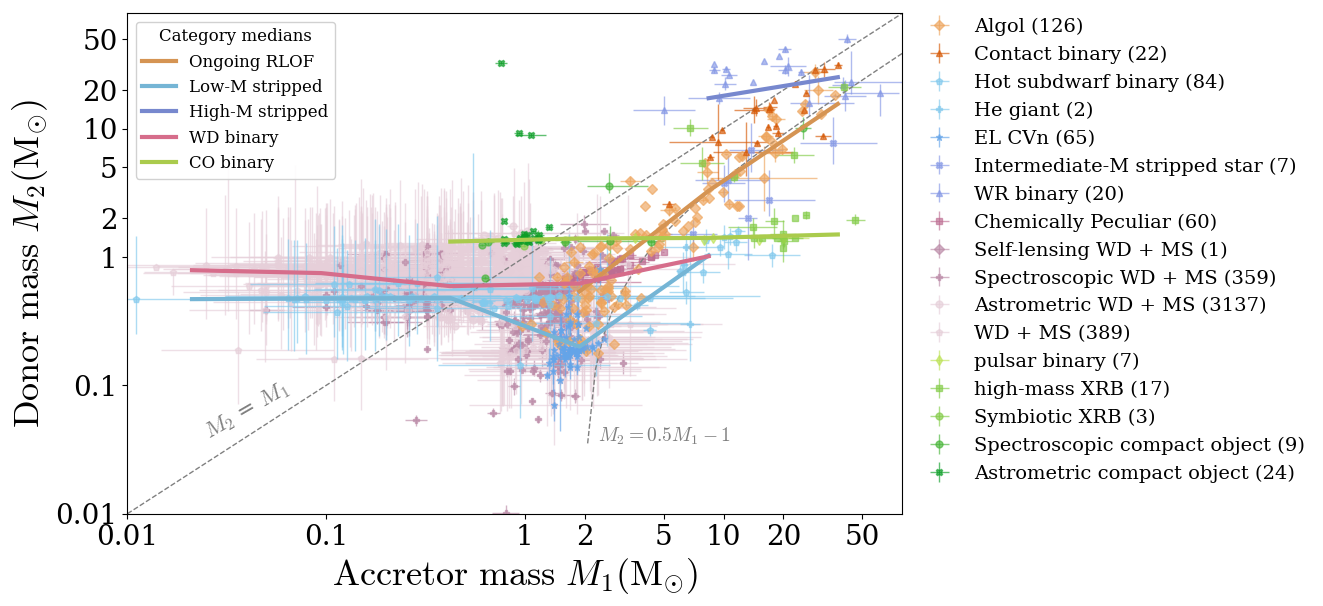

In [12]:
fig, ax = plt.subplots(figsize=(10, 6.5))

plot_df = catalog_df.copy()

###### Prepare log-space quantities ######
# Keep only positive masses for log10 scaling
plot_df = plot_df[(plot_df['M1'] > 0) & (plot_df['M2'] > 0)].copy()
plot_df['log_M1'] = np.log10(plot_df['M1'])
plot_df['log_M2'] = np.log10(plot_df['M2'])

# Propagate errors for logM1 and logM2: d(log M) = dM / (M ln 10)
plot_df['M1_err_minus_log'] = (plot_df['M1_err_minus'] / (plot_df['M1'] * np.log(10))).fillna(0)
plot_df['M1_err_plus_log'] = (plot_df['M1_err_plus'] / (plot_df['M1'] * np.log(10))).fillna(0)
plot_df['M2_err_minus_log'] = (plot_df['M2_err_minus'] / (plot_df['M2'] * np.log(10))).fillna(0)
plot_df['M2_err_plus_log'] = (plot_df['M2_err_plus'] / (plot_df['M2'] * np.log(10))).fillna(0)

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': 'P',
    'cross-dot': 'P',
    'x': 'X',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
}

# Build legend handle lists separately for class points and category fits.
class_handles = []
fit_handles = []

###### Plot all system classes separately ######
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class].copy()
    if sub.empty:
        continue

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    if system_class in SYSTEM_CLASS_MAP["WD binary"]:
        zoder = 0 
    else:        
        zoder = 2

    class_plot = ax.errorbar(
        sub['log_M1'], sub['log_M2'],
        xerr=[sub['M1_err_minus_log'], sub['M1_err_plus_log']],
        yerr=[sub['M2_err_minus_log'], sub['M2_err_plus_log']],
        fmt=marker_mpl, ms=5, c=color, ecolor=color, elinewidth=1, capsize=0,
        alpha=0.65, zorder=zoder,
        label=f"{system_class} ({len(sub)})"
    )
    class_handles.append(class_plot)

###### Keep category fits from combined category subsets ######
for category, systems in SYSTEM_CLASS_MAP.items():
    system_classes_in_category = list(systems.keys())
    subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)].copy()

    fit_df = subset.dropna(subset=['log_M1', 'log_M2'])
    if len(fit_df) < 2:
        continue

    logM1_bins = np.linspace(-2, 1.9, 7)
    x_stats = logM1_bins[:-1] + 0.5 * np.diff(logM1_bins)
    #Get the median and 5-95 percentile for each logM1_bin, ignoring empty bins
    subset['log_M1_bin'] = pd.cut(subset['log_M1'], bins=logM1_bins)
    stats = subset.groupby('log_M1_bin', observed=False)['log_M2'].quantile([0.05, 0.5, 0.95]).unstack()
    stats.columns = ['p05', 'median', 'p95']

    # Use the first class color in the category for the fit line
    first_system_color = list(systems.values())[0]['color']
    fit_color = darken_color(first_system_color, factor=0.9)

    # Plot category median
    fit_line, = ax.plot(x_stats, stats['median'].values, color=fit_color, linewidth=3, zorder=10, label=f"{category}")
    fit_handles.append(fit_line)


# Show x=y line for reference in log space
ax.plot(np.linspace(-2, 2), np.linspace(-2, 2), color='gray', linestyle='--', linewidth=1)
ax.text(-1.4, -1.2, '$M_2$ = $M_1$', color='gray', fontsize=16, ha='center', va='center', rotation=30)

# also show x = 0.7M1 -1.1
x = 10**np.linspace(-4, 1.9, 150)
y = 0.5 * x - 1
ax.plot(np.log10(x), np.log10(y), color='gray', linestyle='--', linewidth=1)
ax.text(0.7, -1.4, '$M_2 = 0.5 M_1 - 1$', color='gray', fontsize=14, ha='center', va='center', rotation=0)

# Write x and y ticks in non-log values
ax.set_xticks([-2, -1, 0, np.log10(2), np.log10(5), 1, np.log10(20), np.log10(50)])
ax.set_xticklabels(['0.01', '0.1', '1', '2', '5', '10', '20', '50'], fontsize=20)
ax.set_yticks([-2, -1, 0, np.log10(2), np.log10(5), 1, np.log10(20), np.log10(50)])
ax.set_yticklabels(['0.01', '0.1', '1', '2', '5', '10', '20', '50'], fontsize=20)


# Separate legends: classes outside in figure coords, fits inside top-left.
legend_fits = ax.legend(
    handles=fit_handles,
    fontsize=12,
    loc='upper left',
    title='Category medians',
    framealpha=0.9
    )

legend_classes = ax.legend(
    handles=class_handles,
    fontsize=14, ncols=1,
    bbox_to_anchor=(0.9, 0.9), loc='upper left',
    bbox_transform=fig.transFigure, framealpha=0. )

ax.add_artist(legend_fits)

# Plot formatting
plt.xlim(-2, 1.9)
plt.ylim(-2, 1.9)
plt.xlabel('$\mathrm{Accretor \ mass} \ M_1 \mathrm{(M_{\odot})}$', fontsize=26)
plt.ylabel('$\mathrm{Donor \ mass} \ M_2 \mathrm{(M_{\odot})}$', fontsize=26)

plt.savefig(LATEX_PLOT_DIR / 'M1_M2_log.pdf', bbox_inches='tight')
plt.savefig(PLOTS_DIR / 'M1_M2_log.pdf', bbox_inches='tight')
plt.show()

# Plot M1 vs M2 per category: linear x and y

Ongoing RLOF:
  M2 = 0.697±0.026 * M1 + -1.171±0.297
  Mass ratio q = M2/M1 ≈ 0.697
Low-M stripped:
  M2 = 0.067±0.007 * M1 + 0.286±0.022
  Mass ratio q = M2/M1 ≈ 0.067
High-M stripped:
  M2 = 0.181±0.178 * M1 + 17.347±4.463
  Mass ratio q = M2/M1 ≈ 0.181
CO binary:
  M2 = 0.077±0.062 * M1 + 2.396±0.841
  Mass ratio q = M2/M1 ≈ 0.077


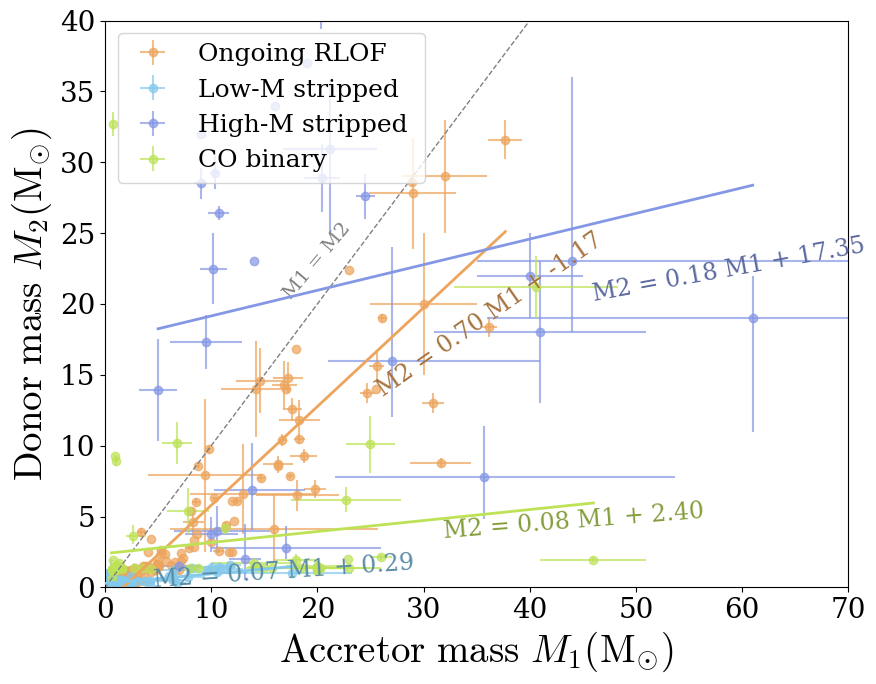

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()

###### Handling errors ######
# Fill NaN errors with zero
plot_df['M1_err_minus'] = plot_df['M1_err_minus'].fillna(0)
plot_df['M1_err_plus'] = plot_df['M1_err_plus'].fillna(0)
plot_df['M2_err_minus'] = plot_df['M2_err_minus'].fillna(0)
plot_df['M2_err_plus'] = plot_df['M2_err_plus'].fillna(0)

# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    if category in ['WD binary', 'Transition to WD']: # these don't show on the linear M plot
        continue
    else:
        # Combine all system classes in this category
        system_classes_in_category = list(systems.keys())
        subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)]
        log_periods = np.log10(subset['Period'].dropna())
        
        first_system_color = list(systems.values())[0]['color']

        ###### Actual plotting ######
        ax.errorbar(subset['M1'], (subset['M2']),
                    xerr=[subset['M1_err_minus'], subset['M1_err_plus']], 
                    yerr=[subset['M2_err_minus'], subset['M2_err_plus']], zorder = 0,
                    fmt='o', c=first_system_color, alpha=0.7,
                    label=f"{category} ")  

        ###### Add polynomal fit ######

        fit_df = subset.dropna(subset=['M1', 'M2'])
        # Define linear function
        def linear_func(x, a, b):
            return a * x + b
        
        # Perform curve_fit
        popt, pcov = curve_fit(linear_func, fit_df['M1'], fit_df['M2'])

        # Generate smooth curve for plotting
        x_fit = np.linspace(fit_df['M1'].min(), fit_df['M1'].max(), 100)
        y_fit = linear_func(x_fit, *popt)
        
        # Plot the fit
        ax.plot(x_fit, y_fit, color=first_system_color, linewidth=2, zorder=10)
        
        # Print results
        a, b = popt
        perr = np.sqrt(np.diag(pcov))
        a_err, b_err = perr
        print(f"{category}:")
        print(f"  M2 = {a:.3f}±{a_err:.3f} * M1 + {b:.3f}±{b_err:.3f}")
        print(f"  Mass ratio q = M2/M1 ≈ {a:.3f}")

        # Annotate the plot with the fit equation     
        ax.text(x_fit[-5], y_fit[-5]-(0.2*y_fit[-5]), f'M2 = {a:.2f} M1 + {b:.2f}', rotation = np.degrees(np.arctan(a)), 
                ha = 'center', va = 'center', fontsize=17, color=darken_color(first_system_color,factor = 0.7), zorder=15)   

# Show x=y line for reference
ax.plot(np.linspace(0,70), np.linspace(0,70), color='gray', linestyle='--', linewidth=1)
# Annotate x=y line
ax.text(20, 23, 'M1 = M2', color='gray', fontsize=14, ha='center', va='center', rotation=50)


# Plot formatting
# Set tick labels to be larger and use mathtext for the x-axis
plt.xlim(0,70)
plt.ylim(0,40)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\mathrm{Accretor \ mass} \ M_1 \mathrm{(M_{\odot})}$', fontsize=28)
plt.ylabel('$\mathrm{Donor \ mass} \ M_2 \mathrm{(M_{\odot})}$', fontsize=28)
plt.legend(loc='upper left', fontsize=18, ncols =1)
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'M1_M2_lin_fit.pdf')
plt.savefig(PLOTS_DIR / 'M1_M2_lin_fit.pdf')
plt.show()

# Plot M1 vs M2 per category: log10 x and y

WD binary:
 log M2 = -0.085±0.009 * log M1 + -0.234±0.002


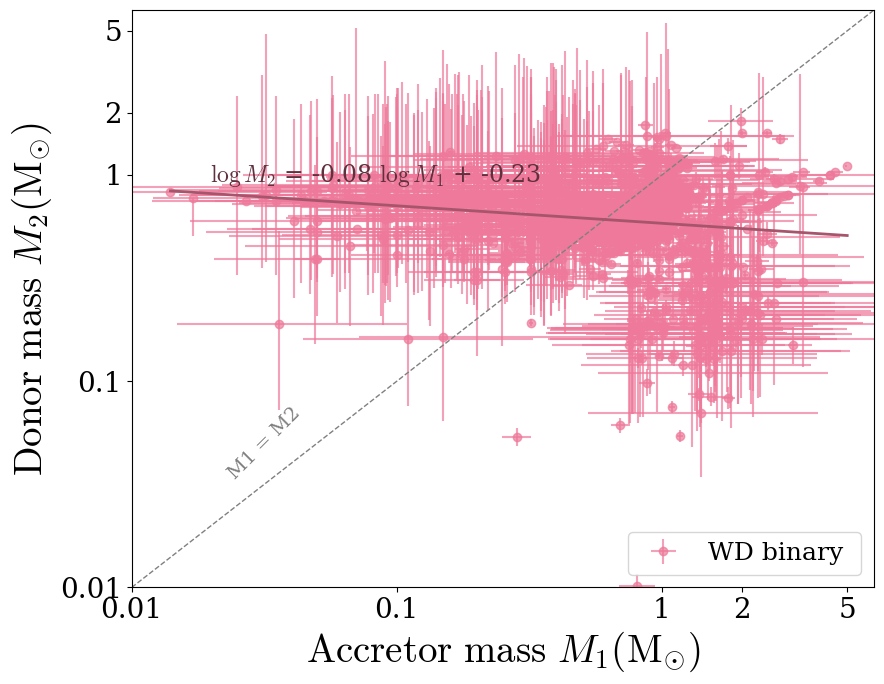

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()
plot_df['log_M1'] = np.log10(plot_df['M1'])
plot_df['log_M2'] = np.log10(plot_df['M2'])

###### Handling errors ######
# Propagate errors for logM1 and logM2: d(log M) = 1/ln(10) *  dM /M 
M1_err_minus_log = plot_df['M1_err_minus'] / (plot_df['M1'] * np.log(10))
M1_err_plus_log = plot_df['M1_err_plus'] / (plot_df['M1'] * np.log(10))
M2_err_minus_log = plot_df['M2_err_minus'] / (plot_df['M2'] * np.log(10))
M2_err_plus_log = plot_df['M2_err_plus'] / (plot_df['M2'] * np.log(10))

# Fill NaN errors with zero
plot_df['M1_err_minus_log'] = M1_err_minus_log.fillna(0)
plot_df['M1_err_plus_log'] = M1_err_plus_log.fillna(0)
plot_df['M2_err_minus_log'] = M2_err_minus_log.fillna(0)
plot_df['M2_err_plus_log'] = M2_err_plus_log.fillna(0)

# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    if category not in ['WD binary', 'Transition to WD']: # these don't show on the linear M plot
        continue
    else:
        # Combine all system classes in this category
        system_classes_in_category = list(systems.keys())
        subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)]
        log_periods = np.log10(subset['Period'].dropna())
        
        first_system_color = list(systems.values())[0]['color']

        ###### Actual plotting ######
        ax.errorbar(subset['log_M1'], (subset['log_M2']),
                    xerr=[subset['M1_err_minus_log'], subset['M1_err_plus_log']], 
                    yerr=[subset['M2_err_minus_log'], subset['M2_err_plus_log']], zorder = 0,
                    fmt='o', c=first_system_color, alpha=0.7,
                    label=f"{category} ")  


        ###### Add polynomal fit ######
        fit_df = subset.dropna(subset=['log_M1', 'log_M2'])
        # Define linear function
        def linear_func(x, a, b):
            return a * x + b
        
        # Perform curve_fit
        popt, pcov = curve_fit(linear_func, fit_df['log_M1'], fit_df['log_M2']) 
        # Generate smooth curve for plotting
        x_fit = np.linspace(fit_df['log_M1'].min(), fit_df['log_M1'].max(), 100)
        y_fit = linear_func(x_fit, *popt)
        
        # Plot the fit
        ax.plot(x_fit, y_fit, color=darken_color(first_system_color,factor = 0.7), linewidth=2, zorder=10)
        
        # Print results
        a, b = popt
        perr = np.sqrt(np.diag(pcov))
        a_err, b_err = perr
        print(f"{category}:")
        print(f" log M2 = {a:.3f}±{a_err:.3f} * log M1 + {b:.3f}±{b_err:.3f}")

        # Annotate the plot with the fit equation     
        ax.text(x_fit[30], y_fit[30]-(0.5*y_fit[-5]), f'$\log M_2$ = {a:.2f} $\log M_1$ + {b:.2f}', rotation = 0,#np.degrees(np.arctan(a)), 
                ha = 'center', va = 'center', fontsize=17, color=darken_color(first_system_color,factor = 0.4), zorder=15)   


# Show x=y line for reference
ax.plot(np.linspace(-2,1), np.linspace(-2,1), color='gray', linestyle='--', linewidth=1)
ax.text(-1.5, -1.3, 'M1 = M2', color='gray', fontsize=14, ha='center', va='center', rotation=45)

# Write x and y ticks in not log format
ax.set_xticks([-2, -1, 0, np.log10(2),np.log10(5)])
ax.set_xticklabels(['0.01', '0.1', '1', '2', '5'], fontsize=20) 
ax.set_yticks([-2, -1, 0, np.log10(2),np.log10(5)])
ax.set_yticklabels(['0.01', '0.1', '1', '2', '5'], fontsize=20)

# Plot formatting
plt.xlim(-2,0.8)
plt.ylim(-2,0.8)
plt.xlabel('$\mathrm{Accretor \ mass} \ M_1 \mathrm{(M_{\odot})}$', fontsize=28)
plt.ylabel('$\mathrm{Donor \ mass} \ M_2 \mathrm{(M_{\odot})}$', fontsize=28)
plt.legend(loc='lower right', fontsize=18, ncols =1)
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'M1_M2_WD_transition_log_fit.pdf')
plt.savefig(PLOTS_DIR / 'M1_M2_WD_transition_log_fit.pdf')
plt.show()

# 1-D Mass distributions

In [69]:

def plot_1d_histogram_with_kde(catalog_df, key, xlim=None, log=True, n_bins=25):
        data_series = catalog_df[key].dropna()
        if log:
                data_series = data_series[data_series > 0]
                if data_series.empty:
                        raise ValueError(f"No positive values available for log-scaled plot of {key}.")
                to_plot_all = np.log10(data_series)
                if xlim is None:
                        data_min = data_series.min()
                        data_max = data_series.max()
                        lower = 10 ** np.floor(np.log10(data_min))
                        upper = 10 ** np.ceil(np.log10(data_max))
                        xlim = (lower, upper)
                bins = np.linspace(np.log10(xlim[0]), np.log10(xlim[1]), n_bins + 1)
                bin_width = bins[1] - bins[0]
                to_plot_xlim = np.log10(xlim)
        else:
                to_plot_all = data_series
                if xlim is None:
                        data_min = data_series.min()
                        data_max = data_series.max()
                        padding = 0.05 * (data_max - data_min) if data_max > data_min else 1.0
                        xlim = (data_min - padding, data_max + padding)
                bins = np.linspace(xlim[0], xlim[1], n_bins + 1)
                bin_width = bins[1] - bins[0]
                to_plot_xlim = xlim
                
        print('to_plot_xlim', to_plot_xlim)
        print(f'Number of bins: {n_bins}')
        sys_classes_in_dict = []

        fig, ax = plt.subplots(figsize=(10, 9))
        # Loop over categories instead of individual system classes
        for category, systems in SYSTEM_CLASS_MAP.items():
                print(f"Plotting category: {category}")
                # Combine all system classes in this category
                system_classes_in_category = list(systems.keys())
                sys_classes_in_dict.append(system_classes_in_category)
                subset = catalog_df[catalog_df['system_class'].isin(system_classes_in_category)]
                to_plot = subset[key].dropna()
                if log:
                        to_plot = to_plot[to_plot > 0]
                        to_plot = np.log10(to_plot)
                # Ensure histogram and KDE are based on the same in-range data.
                to_plot = to_plot[(to_plot >= to_plot_xlim[0]) & (to_plot <= to_plot_xlim[1])]
                
                if len(to_plot) > 1:
                        # Compute histogram counts
                        counts, bin_edges = np.histogram(to_plot, bins=bins)
                        
                        # Normalize by total count
                        counts_normalized = counts / counts.sum()
                        
                        # Plot histogram as bar chart (use first system's color as category color)
                        first_system_color = list(systems.values())[0]['color']
                        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                        plt.bar(bin_centers, counts_normalized, width=bin_width, alpha=0.3, 
                                color=first_system_color, edgecolor='none')
                        
                        # Plot KDE on top (also normalized)
                        kde = gaussian_kde(to_plot, bw_method='scott')
                        x_range = np.linspace(to_plot.min(), to_plot.max(), 200)
                        kde_values = kde(x_range)
                        
                        # Scale KDE to match normalized histogram
                        kde_normalized = kde_values * bin_width
                        
                        plt.plot(x_range, kde_normalized, color=first_system_color, linewidth=2.5, 
                                label=f"{category} (n={len(to_plot)})", alpha=0.9)

        # Plot formatting
        plt.xlim(to_plot_xlim)

        if log:
                tick_values = [tick for tick in [0.1, 1, 10, 100, 1000] if xlim[0] <= tick <= xlim[1]]
                if tick_values:
                        plt.xticks(np.log10(tick_values), [str(tick) for tick in tick_values], fontsize=20)
                else:
                        plt.xticks(fontsize=20)
                plt.xlabel(f'$\\mathrm{{{key} \\ (M_{{\\odot}})}}$', fontsize=28)
        else:
                        plt.xticks(fontsize=20)
                        plt.xlabel(f'${key}$', fontsize=28)
        plt.yticks(fontsize=20)

        plt.ylabel('$\\mathrm{Normalized \\ Frequency}$', fontsize=28)

        plt.legend(loc='upper left', fontsize=18)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f'{key.lower()}_distribution_by_category.pdf')
        plt.show()




# 1D donor dist

to_plot_xlim [-2.  2.]
Number of bins: 25
Plotting category: Ongoing RLOF
Plotting category: Low-M stripped
Plotting category: High-M stripped
Plotting category: WD binary
Plotting category: CO binary


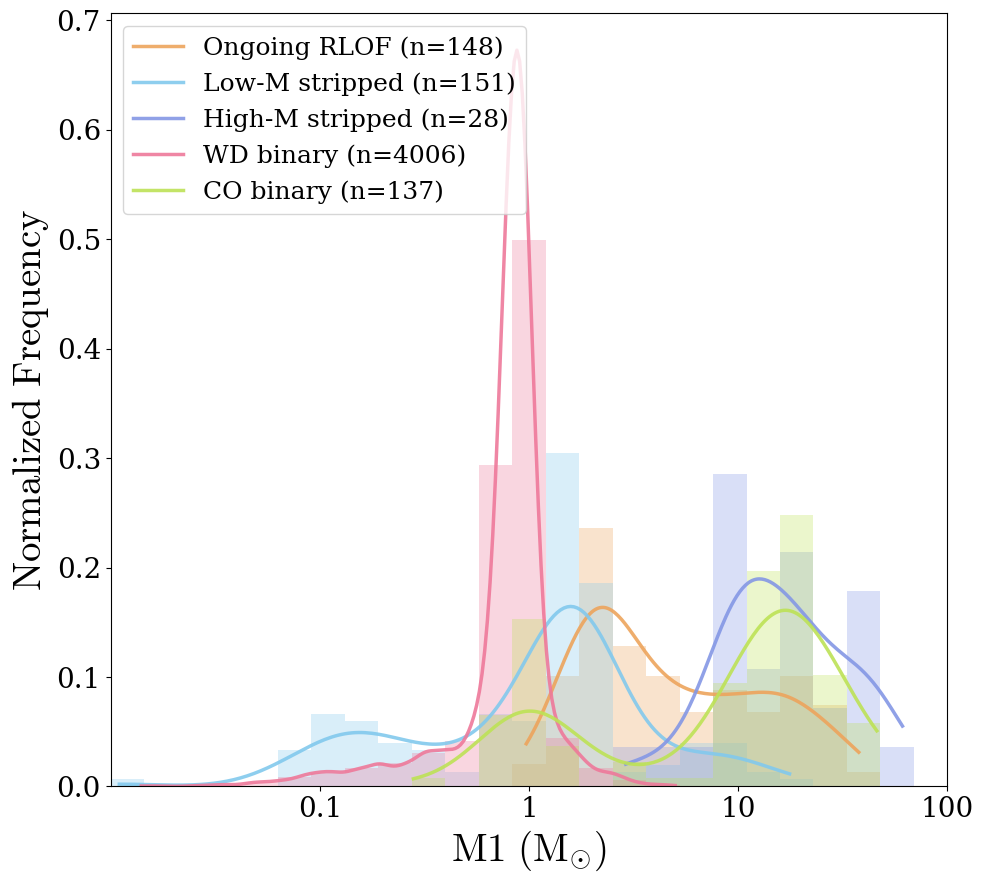

In [70]:
plot_1d_histogram_with_kde(catalog_df, 'M1')

We see that the presumed accretors of high-mass stripped stars and CO binaries are quite similar (HMXRB and WR binaries)
Also the companion/accretor masses of low-mass stripped stars and ongoing RLOF systems have a lot of overlap. 



# 1D Accretor dist

to_plot_xlim [-2.  2.]
Number of bins: 25
Plotting category: Ongoing RLOF
Plotting category: Low-M stripped
Plotting category: High-M stripped
Plotting category: WD binary
Plotting category: CO binary


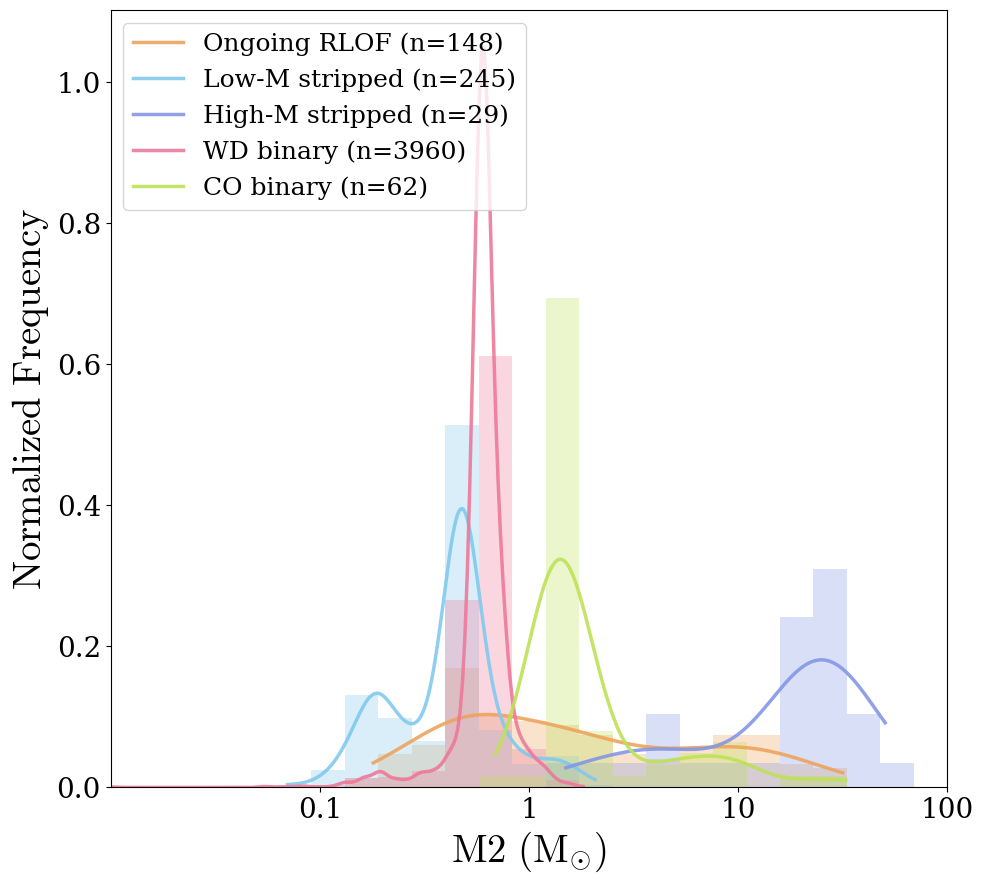

In [71]:
plot_1d_histogram_with_kde(catalog_df, 'M2')

We see that donor masses are generally quite peaked.
low-mass stripped show 2 peaks
as do the CO binaries (NS is a peak and the higher mass tail from BHs)
Again the Algols are most spread, and the high-mass stripped stars have the highest masses by far (i.e., WR stars)

# 1D mass ratio distributions

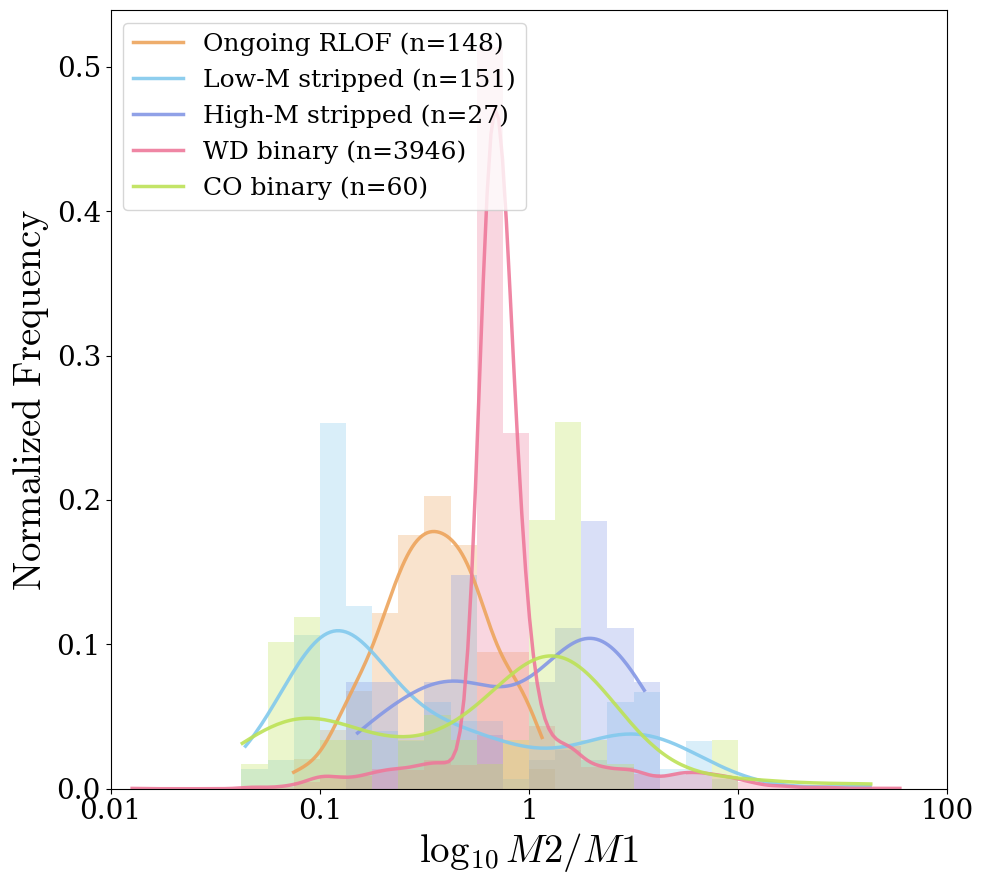

unique system_classes in catalog df ['Algol' 'Astrometric WD + MS' 'Astrometric compact object'
 'Blue straggler binary' 'Chemically Peculiar' 'Contact binary' 'EL CVn'
 'He giant' 'Hot subdwarf binary' 'Intermediate-M stripped star'
 'Post-AGB binary' 'Self-lensing WD + MS' 'Spectroscopic WD + MS'
 'Spectroscopic compact object' 'Symbiotic XRB' 'WD + MS' 'WR binary'
 'high-mass XRB' 'pulsar binary']
system_classes in dict [['Algol', 'Contact binary'], ['Hot subdwarf binary', 'He giant', 'Post-AGB binary', 'EL CVn'], ['Intermediate-M stripped star', 'WR binary'], ['Blue straggler binary', 'Chemically Peculiar', 'Self-lensing WD + MS', 'Spectroscopic WD + MS', 'Astrometric WD + MS', 'WD + MS'], ['pulsar binary', 'high-mass XRB', 'Symbiotic XRB', 'Spectroscopic compact object', 'Astrometric compact object']]


In [ ]:
# Define histogram bins
bins = np.linspace(-1.5, 1.5, 25)
bin_width = bins[1] - bins[0]

sys_classes_in_dict = []

fig, ax = plt.subplots(figsize=(10, 9))
# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    
    # Combine all system classes in this category
    system_classes_in_category = list(systems.keys())
    sys_classes_in_dict.append(system_classes_in_category)
    subset = catalog_df[catalog_df['system_class'].isin(system_classes_in_category)]
    mass_ratios = subset['M2']/subset['M1']
    log_mass_ratios = np.log10(mass_ratios.dropna())
    
    if len(log_mass_ratios) > 1:
        # Compute histogram counts
        counts, bin_edges = np.histogram(log_mass_ratios, bins=bins)
        
        # Normalize by total count
        counts_normalized = counts / counts.sum()
        
        # Plot histogram as bar chart (use first system's color as category color)
        first_system_color = list(systems.values())[0]['color']
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.bar(bin_centers, counts_normalized, width=bin_width, alpha=0.3, 
                color=first_system_color, edgecolor='none')
        
        # Plot KDE on top (also normalized)
        kde = gaussian_kde(log_mass_ratios,  bw_method='scott')
        x_range = np.linspace(log_mass_ratios.min(), log_mass_ratios.max(), 200)
        kde_values = kde(x_range)
        
        # Scale KDE to match normalized histogram
        kde_normalized = kde_values * bin_width
        
        plt.plot(x_range, kde_normalized, color=first_system_color, linewidth=2.5, 
                label=f"{category} (n={len(log_mass_ratios)})", alpha=0.9)

# Plot formatting
plt.xlim(-2,2)
# Write x ticks not in log space but in days
xticks = [0.01, 0.1, 1, 10, 100]
xtick_labels = ['0.01', '0.1', '1', '10', '100']
plt.xticks(np.log10(xticks), xtick_labels, fontsize=20) 

# plt.xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel('$\log_{10} M2/M1$', fontsize=28)
plt.ylabel('$\mathrm{Normalized \ Frequency}$', fontsize=28)

plt.legend(loc='upper left', fontsize=18)
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'period_distribution_by_category.pdf')
plt.savefig(PLOTS_DIR / 'period_distribution_by_category.pdf')
plt.show()



print('unique system_classes in catalog df', np.unique(catalog_df['system_class']))
print('system_classes in dict', sys_classes_in_dict)

to_plot_xlim (0, 4)
Number of bins: 50
Plotting category: Ongoing RLOF
Plotting category: Low-M stripped
Plotting category: High-M stripped
Plotting category: WD binary
Plotting category: CO binary


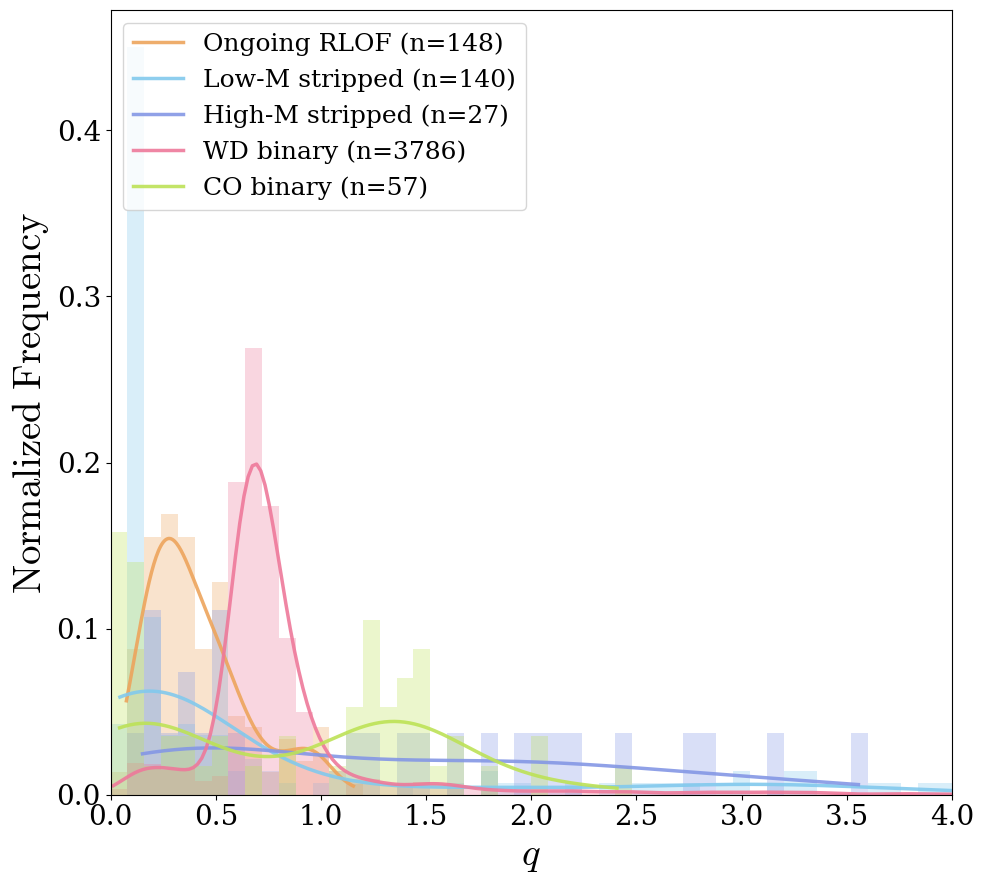

In [76]:
catalog_df['q'] = catalog_df['M2'] / catalog_df['M1']

# Use more bins in the 0..1 range to resolve the q distribution better.
plot_1d_histogram_with_kde(catalog_df, 'q', log=False, xlim=(0,4), n_bins=50)